In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tda_methods import LSTMAutoencoder, GeometryConverter, PersistencePlotter, TakensEmbedding, WassersteinDistance, \
            plot_3d_points, numpy_to_torch, window_2d_sequence_to_3d, write_results_to_file, \
            plot_all_features_in_2d_array, plot_latent_evolution_grid, read_yaml_params
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path


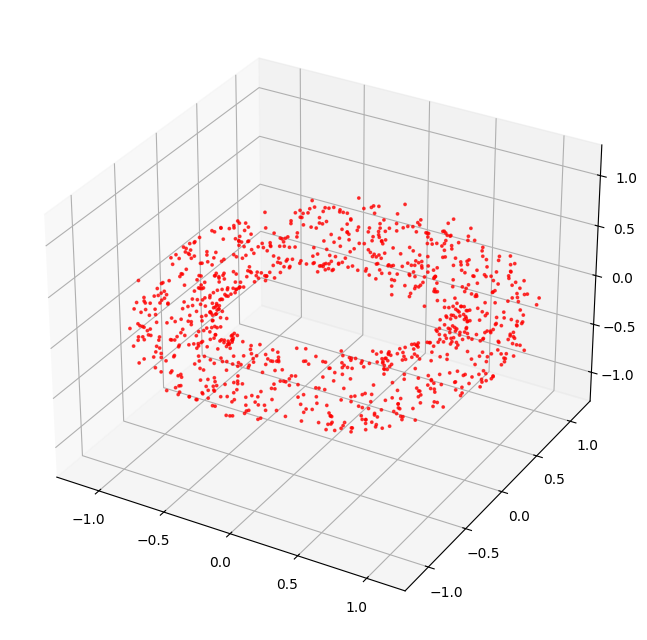

In [2]:
"Torus/Sphere data"

rng     = np.random.default_rng()
start_point, end_point, n_points = 0, 2*np.pi, 1000
u_angle = rng.uniform(start_point, end_point, n_points)
v_angle = rng.uniform(start_point, end_point, n_points)

# u, v = np.meshgrid(u, v)

R_major   = 1
r_tube    = R_major/4
converter = GeometryConverter(R_major, r_tube)
x, y, z   = converter.convert_angles_to_torus_xyz(u_angle, v_angle)
# # x, y, z   = converter.convert_angles_to_sphere_xyz(u_angle, v_angle)
noise = rng.normal(0, 0.04, n_points)
x += noise  # Add some noise to v
y += noise  # Add some noise to u
z += noise  # Add some noise to both
geo_coordinates = np.column_stack((x, y, z))  # shape (N, 3)

# x1,y1,z1,x2,y2,z2 = converter.convert_angles_to_2torus_xyz(u_angle, v_angle, d_shift=R_major)
# geo_coordinates   = np.vstack([np.column_stack((x1,y1,z1)), np.column_stack((x2,y2,z2))])
plot_3d_points((geo_coordinates[:, 0], geo_coordinates[:, 1], geo_coordinates[:, 2]))


In [3]:
"persistence"

# persistence    = PersistencePlotter(max_dim=1)
# diagrams_list  = persistence.compute_persistence_diagrams(geo_coordinates)
# diagrams_clean = persistence.remove_inf(diagrams_list)
# entropy_array  = persistence.compute_entropy(diagrams_clean)
# persistence_images_list = persistence.compute_persistence_image(diagrams_clean)
# betti_curves_array      = persistence.compute_betti_curves(diagrams_clean)

# print("Persistence array:", entropy_array)
# print("Betti curves shape: (batch, homology_dim, filtration_steps) =", betti_curves_array.shape)

# persistence.plot_persistence_diagrams(diagrams_list)
# persistence.plot_entropy(entropy_array)
# persistence.plot_persistence_image(persistence_images_list[1])  # H1
# persistence.plot_betti_curves(betti_curves_array)


'persistence'

In [4]:
"timedelay embeddings"

# x  = np.linspace(0, 14*np.pi, 1000)
# y1 = (0.5+0.5*x) * np.sin(2*x + 1) + 0.04 * rng.normal(size=x.shape)
# y2 = 1.5*np.sin(2 * x) #+ 0.05 * (x-2)**1.2 #+ 0.02 * rng.normal(size=x.shape)
# plt.figure()
# plt.plot(x, y1, label='y1')
# plt.plot(x, y2, label='y2')
# plt.legend()
# plt.show()

# min_len = min(len(y1), len(y2))
# y1, y2  = y1[:min_len], y2[:min_len]

# time_delay, lag_dim = 20, 4
# y1_delay_embeddings = make_timedelay_embeddings(y1, time_delay, lag_dim)
# y1_now, y1_delayed  = y1_delay_embeddings[:, 0], y1_delay_embeddings[:, 1]

# # time_delay2, lag_dim2 = 20, 4
# y2_delay_embeddings = make_timedelay_embeddings(y2, time_delay, lag_dim)
# y2_now, y2_delayed  = y2_delay_embeddings[:, 0], y2_delay_embeddings[:, 1]
# plt.figure()
# # plt.scatter(y1_now, y1_delayed, s=4)
# plt.scatter(y2_now, y2_delayed, s=4)
# plt.show()

# # persistence stuff
# persistence  = PersistencePlotter(max_dim=1)
# n            = min(len(y1_delay_embeddings), len(y2_delay_embeddings))
# y_all        = np.hstack((y1_delay_embeddings[:n], y2_delay_embeddings[:n]))
# # y_data       = np.column_stack((y1_now, y1_delayed))
# diagrams_list = persistence.compute_persistence_diagrams(y_all)
# persistence.plot_persistence_diagrams(diagrams_list, title="y_all")


'timedelay embeddings'

In [5]:
"⚽️ yaml params"
geo_params           = read_yaml_params(file_path="control_panel.yaml")

X_windowing_params   = geo_params["general"]["X_windowing"]
X_window_size        = X_windowing_params["window_size"]
X_stride_frac        = X_windowing_params["stride_frac"]

LSTMAE_params             = geo_params["general"]["LSTM_AE"]
lstmae_latent_dim         = LSTMAE_params["latent_dim"]
lstmae_encoder_hidden_dim = LSTMAE_params["encoder_hidden_dim"]
lstmae_decoder_hidden_dim = LSTMAE_params["decoder_hidden_dim"]
lstmae_patience           = LSTMAE_params["patience"]
lstm_ae_epochs            = LSTMAE_params["epochs"]
lstmae_learning_rate      = LSTMAE_params["learning_rate"]
lstmae_lambda_topo        = LSTMAE_params["lambda_topo"]
lstmae_batch_size         = LSTMAE_params["batch_size"]
topo_every                = LSTMAE_params["topo_every"]
N_runs                    = LSTMAE_params["N_runs"]
lambda_forecast           = LSTMAE_params["lambda_forecast"]

z_windowing_params   = geo_params["general"]["z_windowing"]
z_window_frac        = z_windowing_params["z_window_frac"]
z_stride_frac        = z_windowing_params["z_stride_frac"]

z_forecaster_params  = geo_params["general"]["z_forecaster"]
H_forecaster         = z_forecaster_params["H"]
hidden_dim_forecaster= z_forecaster_params["hidden_dim"]
forecaster_epochs    = z_forecaster_params["epochs"]
forecaster_patience  = z_forecaster_params["earlystop_patience"]
forecaster_lr        = z_forecaster_params["lr"]
forecaster_batch_size= z_forecaster_params["batch_size"]

persistence_params = geo_params["general"]["persistence"]
max_dim            = persistence_params["max_dim"]
pixel_size         = persistence_params["pixel_size"]


In [6]:
"⚽️ Setting up data"
rng     = np.random.default_rng()

num_timesteps = 3_000
timesteps     = np.linspace(0, 20*np.pi, num_timesteps)
# X1 = (2.0 * np.sin(0.2 * timesteps)) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
# X2 = np.cos(3*timesteps + 1) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
# X3 = -(4.0 * np.sin(0.8 * timesteps)) + 0.8 * np.sin(4*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
X1 = np.sin(timesteps) + np.sin(0.1* timesteps**2) + 0.03 * rng.normal(size=timesteps.shape)
X2 = np.cos(1.7 * timesteps + X1) + 0.03 * rng.normal(size=timesteps.shape)
X3 = np.sin(X2 * X1) + 0.03 * rng.normal(size=timesteps.shape)
X  = np.column_stack((X1, X2, X3))

X_stride        = X_window_size//X_stride_frac
X_windows       = window_2d_sequence_to_3d(X, X_window_size, X_stride)
X_train_3d, X_test_3d = train_test_split(X_windows, test_size=0.2, random_state=42, shuffle=False)

# ============
# "⚽️ real dataset"

# import sys
# sys.path.append('../..')
# from src.preprocessing.data_loader_module import DatasetLoading

# dataset_loader_obj = DatasetLoading()
# X_all, y_all = dataset_loader_obj.load_beijing_data()

# # 1. split first (important)
# X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

# # 2. reshape to 2D
# N, T, F    = X_train.shape
# X_train_2d = X_train.reshape(-1, F)
# X_test_2d  = X_test.reshape(-1, F)

# # 3. fit scaler on train only
# scaler         = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_2d)
# X_test_scaled  = scaler.transform(X_test_2d)

# # 4. reshape back to 3D
# X_train = X_train_scaled.reshape(N, T, F)
# X_test  = X_test_scaled.reshape(X_test.shape[0], T, F)
# print(X_train.shape, X_test.shape)



X shape (3000, 3) X_windows shape: (57, 200, 3)
X_train/test shape: (45, 200, 3) (12, 200, 3)


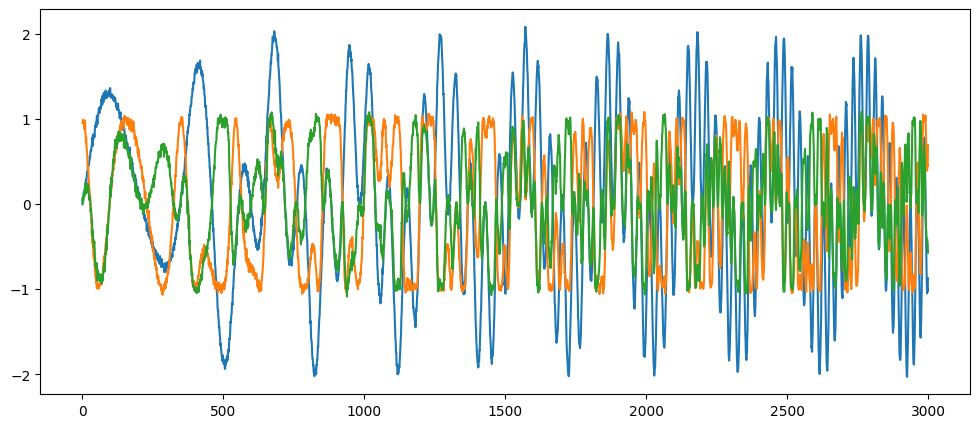

In [7]:
"⚽️ data processing"
# scaling works for 2d, so reshape to 2d, scale, and reshape back
scaler         = StandardScaler()
X_train_2d     = X_train_3d.reshape(-1, X_train_3d.shape[-1])
X_test_2d      = X_test_3d.reshape(-1, X_test_3d.shape[-1])
X_train = scaler.fit_transform(X_train_2d).reshape(X_train_3d.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test_3d.shape)

# takens_object   = TakensEmbedding(delay=8, embedding_dim=3)
# X_train_takens  = takens_object.make_timedelay_embeddings_grid(X_train)
# X_test_takens   = takens_object.make_timedelay_embeddings_grid(X_test)

print("X shape", X.shape, "X_windows shape:", X_windows.shape)
print("X_train/test shape:", X_train.shape, X_test.shape)

plt.figure(figsize=(12, 5))
plt.plot(X1, label='Original Data')
plt.plot(X2, label='Original Data')
plt.plot(X3, label='Original Data')


In [10]:
"🎯⚽️ models"

def topology_loss(x: torch.Tensor,
                  x_hat: torch.Tensor,
                  plotter,
                  wasser,
                  mode: str = "betti") -> torch.Tensor:
    """Computes Wasserstein distance between persistence features of x and x_hat."""
    x_np  = x.detach().cpu().numpy()
    xh_np = x_hat.detach().cpu().numpy()

    f_x  = plotter.compute_persistence_features(x_np, mode=mode)
    f_xh = plotter.compute_persistence_features(xh_np, mode=mode)

    if len(f_x) == 0 or len(f_xh) == 0:
        return torch.tensor(0.0, device=x.device)

    d = wasser.compute_wasserstein_distance(f_x, f_xh, delay=1).mean()
    return torch.tensor(d, device=x.device)#.clamp(0, 10)

def train_lstm_topo_ae(model,
                       X,
                       plotter,
                       wasser,
                       epochs,
                       batch_size,
                       lr,
                       lambda_topo,
                       device=None):

    device = device or model.device
    model.to(device)
    X = X.to(device)

    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=True)

    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    for epoch in range(epochs):
        total = 0.0

        for step, (xb,) in enumerate(loader):
            xb = xb.to(device)

            x_hat, z = model(xb)

            # reconstruction
            loss_rec = mse(x_hat, xb)

            # topology in LATENT ONLY
            z_hat = model.encode(x_hat)

            with torch.no_grad():
                z_detached = z.detach()

            z_hat = model.encode(x_hat)

            loss_topo = topology_loss_latent(z_detached, z_hat, plotter, wasser)

            loss = loss_rec + lambda_topo * loss_topo

            opt.zero_grad()
            loss.backward()
            opt.step()

            total += loss.item()

            print(
                f"epoch {epoch} step {step} | "
                f"rec {loss_rec.item():.4f} | "
                f"topo {loss_topo.item():.4f} | "
                f"total {loss.item():.4f}"
            )

        print(f"epoch {epoch} avg {total/len(loader):.4f}")

    return model

def topology_loss_latent(z, z_hat, plotter, wasser, mode="betti"):
    losses = []

    for i in range(z.shape[0]):
        # .unsqueeze(0) ensures the plotter sees a "batch" of 1 window
        # which matches the internal logic of _cache_diagrams
        zi  = z[i:i+1].detach().cpu().numpy() 
        zhi = z_hat[i:i+1].detach().cpu().numpy()

        # Ensure we have (1, sequence_length, features)
        if zi.ndim == 2:
            zi = zi[None, :, :]
        if zhi.ndim == 2:
            zhi = zhi[None, :, :]

        try:
            f_z  = plotter.compute_persistence_features(zi, mode=mode)
            f_zh = plotter.compute_persistence_features(zhi, mode=mode)
            
            if f_z.size == 0 or f_zh.size == 0:
                continue

            d = wasser.compute_wasserstein_distance(f_z, f_zh, delay=1)
            losses.append(torch.as_tensor(d.mean(), device=z.device))
        except Exception:
            # Handle cases where Ripser fails on very small/uniform latent noise
            continue

    if len(losses) == 0:
        return torch.tensor(0.0, device=z.device, requires_grad=True)

    return torch.stack(losses).mean()

def save_model(model, path: str):
    """Save model weights."""
    torch.save(model.state_dict(), path)

def load_model(path: str, input_dim: int, hidden_dim: int, device):
    """Reload trained model."""
    model = ZForecaster(input_dim=input_dim, hidden_dim=hidden_dim).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model


epoch 0 step 0 | rec 1.0350 | topo 21.0572 | total 7.3522
epoch 0 avg 7.3522
epoch 1 step 0 | rec 1.0261 | topo 21.3463 | total 7.4299
epoch 1 avg 7.4299
epoch 2 step 0 | rec 1.0172 | topo 21.3656 | total 7.4269
epoch 2 avg 7.4269
epoch 3 step 0 | rec 1.0084 | topo 20.7439 | total 7.2315
epoch 3 avg 7.2315
epoch 4 step 0 | rec 0.9996 | topo 21.4759 | total 7.4424
epoch 4 avg 7.4424
z_train: torch.Size([45, 200, 8]) z_test: torch.Size([12, 200, 8])


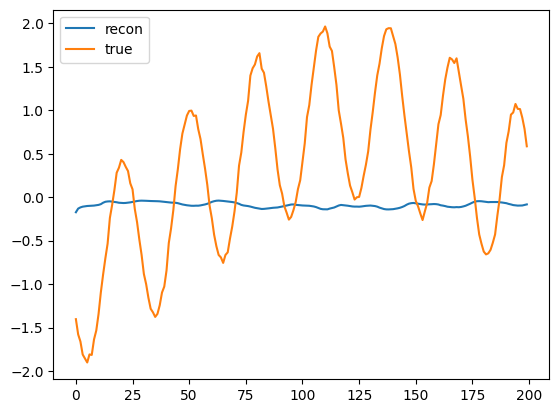

In [11]:
"⚽️ LSTMAE encoder: train + eval"

plotter = PersistencePlotter(max_dim=max_dim, pixel_size=pixel_size)
wasser  = WassersteinDistance()

X_train, X_test = numpy_to_torch(X_train), numpy_to_torch(X_test)

input_dim = X_train.shape[-1]

lstm_ae = LSTMAutoencoder(
    input_dim=input_dim,
    latent_dim=lstmae_latent_dim,
    encoder_hidden_dim=lstmae_encoder_hidden_dim,
    decoder_hidden_dim=lstmae_decoder_hidden_dim).to("cuda" if torch.cuda.is_available() else "cpu")

device = lstm_ae.device

# TRAIN (topology-aware AE)
train_lstm_topo_ae(
    model=lstm_ae,
    X=X_train,
    plotter=plotter,
    wasser=wasser,
    epochs=lstm_ae_epochs,
    batch_size=lstmae_batch_size,
    lr=lstmae_learning_rate,
    lambda_topo=lstmae_lambda_topo)

# inference
lstm_ae.eval()
with torch.no_grad():
    x_train_hat, z_train = lstm_ae(X_train.to(device))
    x_test_hat, z_test   = lstm_ae(X_test.to(device))

# normalize latent
mean = z_train.mean(dim=0)
std  = z_train.std(dim=0) + 1e-8
z_train = (z_train - mean) / std
z_test  = (z_test - mean) / std

print("z_train:", z_train.shape, "z_test:", z_test.shape)

# sanity check reconstruction
plt.plot(x_test_hat[2, :, 0].cpu(), label="recon")
plt.plot(X_test[2, :, 0].cpu(), label="true")
plt.legend()
plt.show()

In [ ]:
plt.scatter(z_train[0, :, 0].cpu(), z_train[0, :, 1].cpu(), label='Latent Dim 1')
plt.title('LSTM AE Latent Space')

z_train=torch.Size([45, 200, 8]), z_test=torch.Size([12, 200, 8])
Plotting features for window 1 (dataset shape: torch.Size([45, 200, 8]))


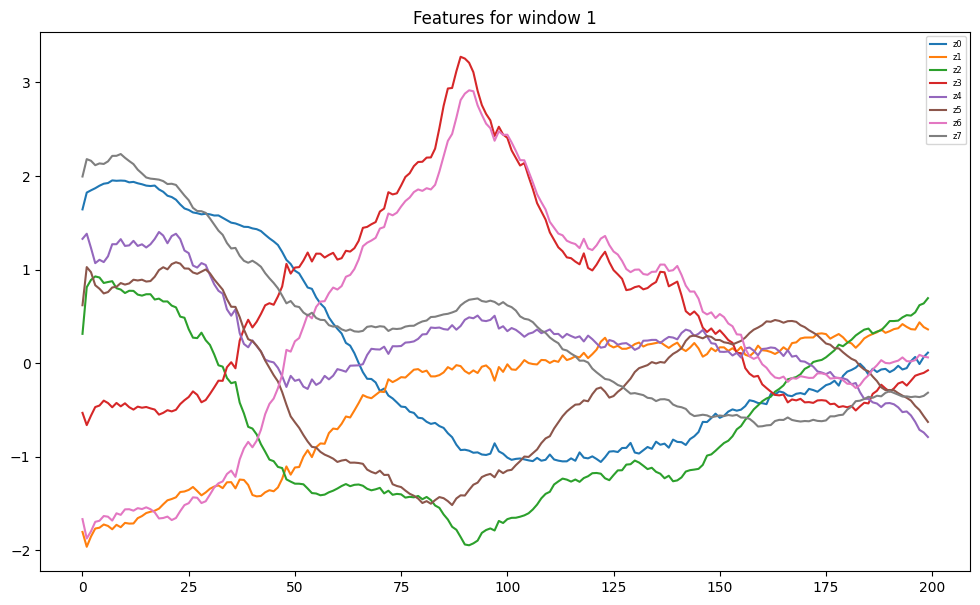

In [12]:
"⚽️ windowing latents z"

# actual_z_win_size = int(len(z_train) * z_window_frac)
# actual_z_stride   = int(len(z_train) * z_stride_frac)
# z_train_windows   = window_2d_sequence_to_3d(z_train, actual_z_win_size, actual_z_stride)
# z_test_windows    = window_2d_sequence_to_3d(z_test,  actual_z_win_size, actual_z_stride)

print(f"z_train={z_train.shape}, z_test={z_test.shape}")
# print(f"z_train_win= {z_train_windows.shape}, z_test_win= {z_test_windows.shape}")
plot_all_features_in_2d_array(z_train, window_number=1)
# plot_latent_evolution_grid(z_train_windows, max_latent_dims=8, n_plots_per_row=4)


In [ ]:
"⚠️ moved takens stuff temporarily here"

# takens_obj     = TakensEmbedding(delay=10, embedding_dim=3)
# z_train_takens = takens_obj.make_timedelay_embeddings_grid(z_train_windows)
# z_test_takens  = takens_obj.make_timedelay_embeddings_grid(z_test_windows)
# # plotter        = PersistencePlotter(max_dim=2, pixel_size=0.2)
# # dgms           = plotter.remove_inf(plotter.compute_persistence_diagrams(z_train_takens[0]))

# print(f"z_win_takens= {z_train_takens.shape}")

# plotter.plot_persistence_diagrams(dgms)

# # A(t) = mean_k corr(z[:,k], z[:,k+τ]) # acf decides the best window size

# window = 2
# plot_3d_points((z_train_takens[window][:, 0], z_train_takens[window][:, 1], z_train_takens[window][:, 2]), figsize=(6, 9))
# plot_3d_points((z_train_windows[window][:, 0], z_train_windows[window][:, 1], z_train_windows[window][:, 2]), figsize=(6, 9))

In [ ]:
# "⚠️⚽️ persistence + d_wasserstein + plotting"
# # TODO: is this cell really needed?

# plotter = PersistencePlotter(max_dim=2, pixel_size=0.2)
# d_wasser_obj = WassersteinDistance

# # ALIGNMENT FIX (⚠️ when H != 1, need to fix the [1:] bit in the next 4 lines)
# z_true_test = z_test_windows[1:]   # (9, 100, 8)
# z_hat_test  = Z_hat_test           # (9, 100, 8)

# z_true_train = z_train_windows[1:]
# z_hat_train  = Z_hat_train

# print("train aligned:", z_true_train.shape, z_hat_train.shape)
# print("test aligned :", z_true_test.shape, z_hat_test.shape)

# # PERSISTENCE FEATURES
# true_betti_train = plotter.compute_persistence_features(z_true_train, mode="betti")
# hat_betti_train  = plotter.compute_persistence_features(z_hat_train, mode="betti")

# true_betti_test = plotter.compute_persistence_features(z_true_test, mode="betti")
# hat_betti_test  = plotter.compute_persistence_features(z_hat_test, mode="betti")

# # TOPOLOGY LOSS (WASSERSTEIN)
# betti_dist_train = d_wasser_obj.compute_wasserstein_distance(true_betti_train, hat_betti_train, delay=1)
# betti_dist_test  = d_wasser_obj.compute_wasserstein_distance(true_betti_test, hat_betti_test, delay=1)

# # OUTPUT SHAPES + SUMMARY
# print("train betti dist shape:", betti_dist_train.shape)
# print("test betti dist shape :", betti_dist_test.shape)

# print("train mean topo error:", betti_dist_train.mean().item())
# print("test mean topo error :", betti_dist_test.mean().item())

# # ==============
# # X_hat, non-Takens

# # plotter        = PersistencePlotter(max_dim=2, pixel_size=0.2)
# # dgms           = plotter.remove_inf(plotter.compute_persistence_diagrams(Z_hat_train[0]))
# # z_betti_train    = plotter.compute_persistence_features(Z_hat_train, mode="betti")
# # z_image_train    = plotter.compute_persistence_features(Z_hat_train, mode="image")
# # z_diagram_train  = plotter.compute_persistence_features(Z_hat_train, mode="diagram")
# # z_landscape_train= plotter.compute_persistence_features(Z_hat_train, mode="landscape")

# # z_betti_test    = plotter.compute_persistence_features(Z_hat_test, mode="betti")
# # z_image_test    = plotter.compute_persistence_features(Z_hat_test, mode="image")
# # z_diagram_test  = plotter.compute_persistence_features(Z_hat_test, mode="diagram")
# # z_landscape_test= plotter.compute_persistence_features(Z_hat_test, mode="landscape")

# # d_wasser_obj         = WassersteinDistance
# # betti_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_betti_train, delay=1)
# # image_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_image_train, delay=1)
# # diagram_dist_train   = d_wasser_obj.compute_wasserstein_distance(z_diagram_train, delay=1)
# # landscape_dist_train = d_wasser_obj.compute_wasserstein_distance(z_landscape_train, delay=1)

# # betti_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_betti_test, delay=1)
# # image_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_image_test, delay=1)
# # diagram_dist_test   = d_wasser_obj.compute_wasserstein_distance(z_diagram_test, delay=1)
# # landscape_dist_test = d_wasser_obj.compute_wasserstein_distance(z_landscape_test, delay=1)

# # print(np.array2string(betti_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(image_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(diagram_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(landscape_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))

# # d_wasser_obj.plot_all_wasserstein_distances(betti_dist_train, image_dist_train, diagram_dist_train, landscape_dist_train)

# # ===============
# # Takens

# # z_betti_train    = plotter.compute_persistence_features(z_train_takens, mode="betti")
# # z_image_train    = plotter.compute_persistence_features(z_train_takens, mode="image")
# # z_diagram_train  = plotter.compute_persistence_features(z_train_takens, mode="diagram")
# # z_landscape_train= plotter.compute_persistence_features(z_train_takens, mode="landscape")

# # z_betti_test    = plotter.compute_persistence_features(z_test_takens, mode="betti")
# # z_image_test    = plotter.compute_persistence_features(z_test_takens, mode="image")
# # z_diagram_test  = plotter.compute_persistence_features(z_test_takens, mode="diagram")
# # z_landscape_test= plotter.compute_persistence_features(z_test_takens, mode="landscape")

# # print("betti features shape:", z_betti_train.shape)
# # plotter.plot_persistence_grid(z_train_windows)
# # plotter.plot_persistence_image_grid(z_train_windows)
# # plotter.plot_betti_grid(z_train_windows)
# # plotter.plot_landscape_grid(z_train_windows, num_steps=128, K_layers=3)

# # d_wasser_obj         = WassersteinDistance
# # betti_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_betti_train, delay=1)
# # image_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_image_train, delay=1)
# # diagram_dist_train   = d_wasser_obj.compute_wasserstein_distance(z_diagram_train, delay=1)
# # landscape_dist_train = d_wasser_obj.compute_wasserstein_distance(z_landscape_train, delay=1)

# # betti_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_betti_test, delay=1)
# # image_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_image_test, delay=1)
# # diagram_dist_test   = d_wasser_obj.compute_wasserstein_distance(z_diagram_test, delay=1)
# # landscape_dist_test = d_wasser_obj.compute_wasserstein_distance(z_landscape_test, delay=1)

# # print(np.array2string(betti_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(image_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(diagram_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# # print(np.array2string(landscape_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))

# # d_wasser_obj.plot_all_wasserstein_distances(betti_dist_train, image_dist_train, diagram_dist_train, landscape_dist_train)


In [13]:
"⚽️ results + comparisons"
from torchmetrics.regression import R2Score
from sklearn.linear_model import LinearRegression

def compute_r2(pred, true, device):
    r2 = R2Score().to(device)
    p = pred.reshape(-1, pred.shape[-1]).to(device)
    t = true.reshape(-1, true.shape[-1]).to(device)
    return r2(p, t).item()

def compute_linear_baseline(X_train, X_test):
    """Linear regression baseline in input space (next-step prediction)."""

    X_train_flat = X_train[:-1].reshape(X_train.shape[0]-1, -1).cpu().numpy()
    Y_train_flat = X_train[1:].reshape(X_train.shape[0]-1, -1).cpu().numpy()

    X_test_flat  = X_test[:-1].reshape(X_test.shape[0]-1, -1).cpu().numpy()
    Y_test_flat  = X_test[1:].reshape(X_test.shape[0]-1, -1).cpu().numpy()

    reg = LinearRegression().fit(X_train_flat, Y_train_flat)

    Y_pred = reg.predict(X_test_flat)
    Y_pred = Y_pred.reshape(Y_test_flat.shape)

    mse = np.mean((Y_pred - Y_test_flat) ** 2)
    return mse

def evaluate_run(model, X_test, device):
    """Reconstruction evaluation only (TopoAE setting)."""

    model.eval()
    with torch.no_grad():
        X_test = X_test.to(device)

        x_hat, _ = model(X_test)

        mse_model = ((x_hat - X_test) ** 2).mean().item()

        # naive baseline: copy last step forward (stupid baseline)
        x_naive = torch.cat([X_test[:, :1, :], X_test[:, :-1, :]], dim=1)
        mse_naive = ((x_naive - X_test) ** 2).mean().item()

        r2_model = compute_r2(x_hat, X_test, device)
        r2_naive = compute_r2(x_naive, X_test, device)

        pct_improvement = ((mse_naive - mse_model) / mse_naive) * 100

    return mse_model, r2_model, mse_naive, r2_naive, pct_improvement

# ---------------- RUN LOOP ----------------
results_storage = []

print(f"🚀 Starting {N_runs} runs")

for i in range(N_runs):
    metrics = evaluate_run(lstm_ae, X_test, lstm_ae.device)
    results_storage.append(metrics)
    mse_linear = compute_linear_baseline(X_train, X_test)

    print(
        f"Run {i+1}/{N_runs} | "
        f"MSE: {metrics[0]:.4f} | "
        f"R2: {metrics[1]:.3f} | "
        f"Improv: {metrics[4]:.2f}% | "
        f"Linear: {mse_linear:.4f}")

# ---------------- SUMMARY ----------------
res_arr = np.array(results_storage)

mean_mse = res_arr[:, 0].mean()
std_mse  = res_arr[:, 0].std()
mean_r2  = res_arr[:, 1].mean()
std_r2   = res_arr[:, 1].std()

results_line = (
    f"TopoAE | "
    f"MSE: {mean_mse:.4f} ± {std_mse:.4f} | "
    f"R2: {mean_r2:.3f} ± {std_r2:.3f}\n")

write_results_to_file(file="results.txt", line=results_line)
print(results_line)

🚀 Starting 1 runs
Run 1/1 | MSE: 0.9726 | R2: 0.003 | Improv: -2289.36% | Linear: 0.8692
TopoAE | MSE: 0.9726 ± 0.0000 | R2: 0.003 ± 0.000

